## Import istotnych bibliotek

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
from itertools import cycle
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.decomposition import PCA
from collections import defaultdict
from sklearn.preprocessing import label_binarize
from sklearn.preprocessing import StandardScaler
from sklearn.multiclass import OneVsRestClassifier
from sklearn import svm
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import scale
from scipy import stats
import warnings
warnings.filterwarnings("ignore")

## Podział danych na treningowe i testowe

In [2]:
df = pd.read_csv('./datasets/VLagun_Total_Years_depth.csv')
print(df.shape)
dftrain, dftest = train_test_split(df, test_size=0.3, random_state=42)


dftrain.head()

(155, 57)


,PSU,O2,temp.,SS,SRP,DOP,PP,NH4N,NO3N,DON,...,Keratella cochlearis cochlearis,Keratella cochlearis f.tecta,Keratella quadrata,Polyarthra vulgaris,Polyarthra platyptera,Pompholyx sp.,Synchaeta sp.,Trichocerca pusilla,Trichocerca similis,Depth
141,1.80,10.35,20.2,65.00,18.2,12.4,157.9,0.014,0.057,0.578,...,0.303,0.043,0.000,0.248,0.0,0.0,0.00,0.013,0.005,3.0
66,3.30,9.66,20.3,58.80,9.2,12.5,146.7,0.016,0.039,0.577,...,2.541,0.008,0.026,0.000,0.0,0.0,0.05,0.000,0.004,3.5
119,4.23,9.77,10.9,114.00,7.3,45.0,231.6,0.034,0.054,0.741,...,0.021,0.003,0.000,0.000,0.0,0.0,0.00,0.000,0.000,1.5
27,3.54,12.89,20.6,64.29,21.1,9.0,247.6,0.030,0.050,0.755,...,0.019,0.002,0.000,0.000,0.0,0.0,0.00,0.000,0.000,1.5
79,3.70,8.42,20.5,92.50,8.2,12.1,165.8,0.024,0.024,0.553,...,0.020,0.013,0.000,0.000,0.0,0.0,0.00,0.000,0.000,3.0


In [3]:
dftrain.info()

<class 'pandas.core.frame.DataFrame'>
Index: 108 entries, 141 to 102
Data columns (total 57 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   PSU                                     108 non-null    float64
 1   O2                                      108 non-null    float64
 2   temp.                                   108 non-null    float64
 3   SS                                      108 non-null    float64
 4   SRP                                     108 non-null    float64
 5   DOP                                     108 non-null    float64
 6   PP                                      108 non-null    float64
 7   NH4N                                    108 non-null    float64
 8   NO3N                                    108 non-null    float64
 9   DON                                     108 non-null    float64
 10  PN                                      108 non-null    float64
 

# Heatmapa

<Axes: >

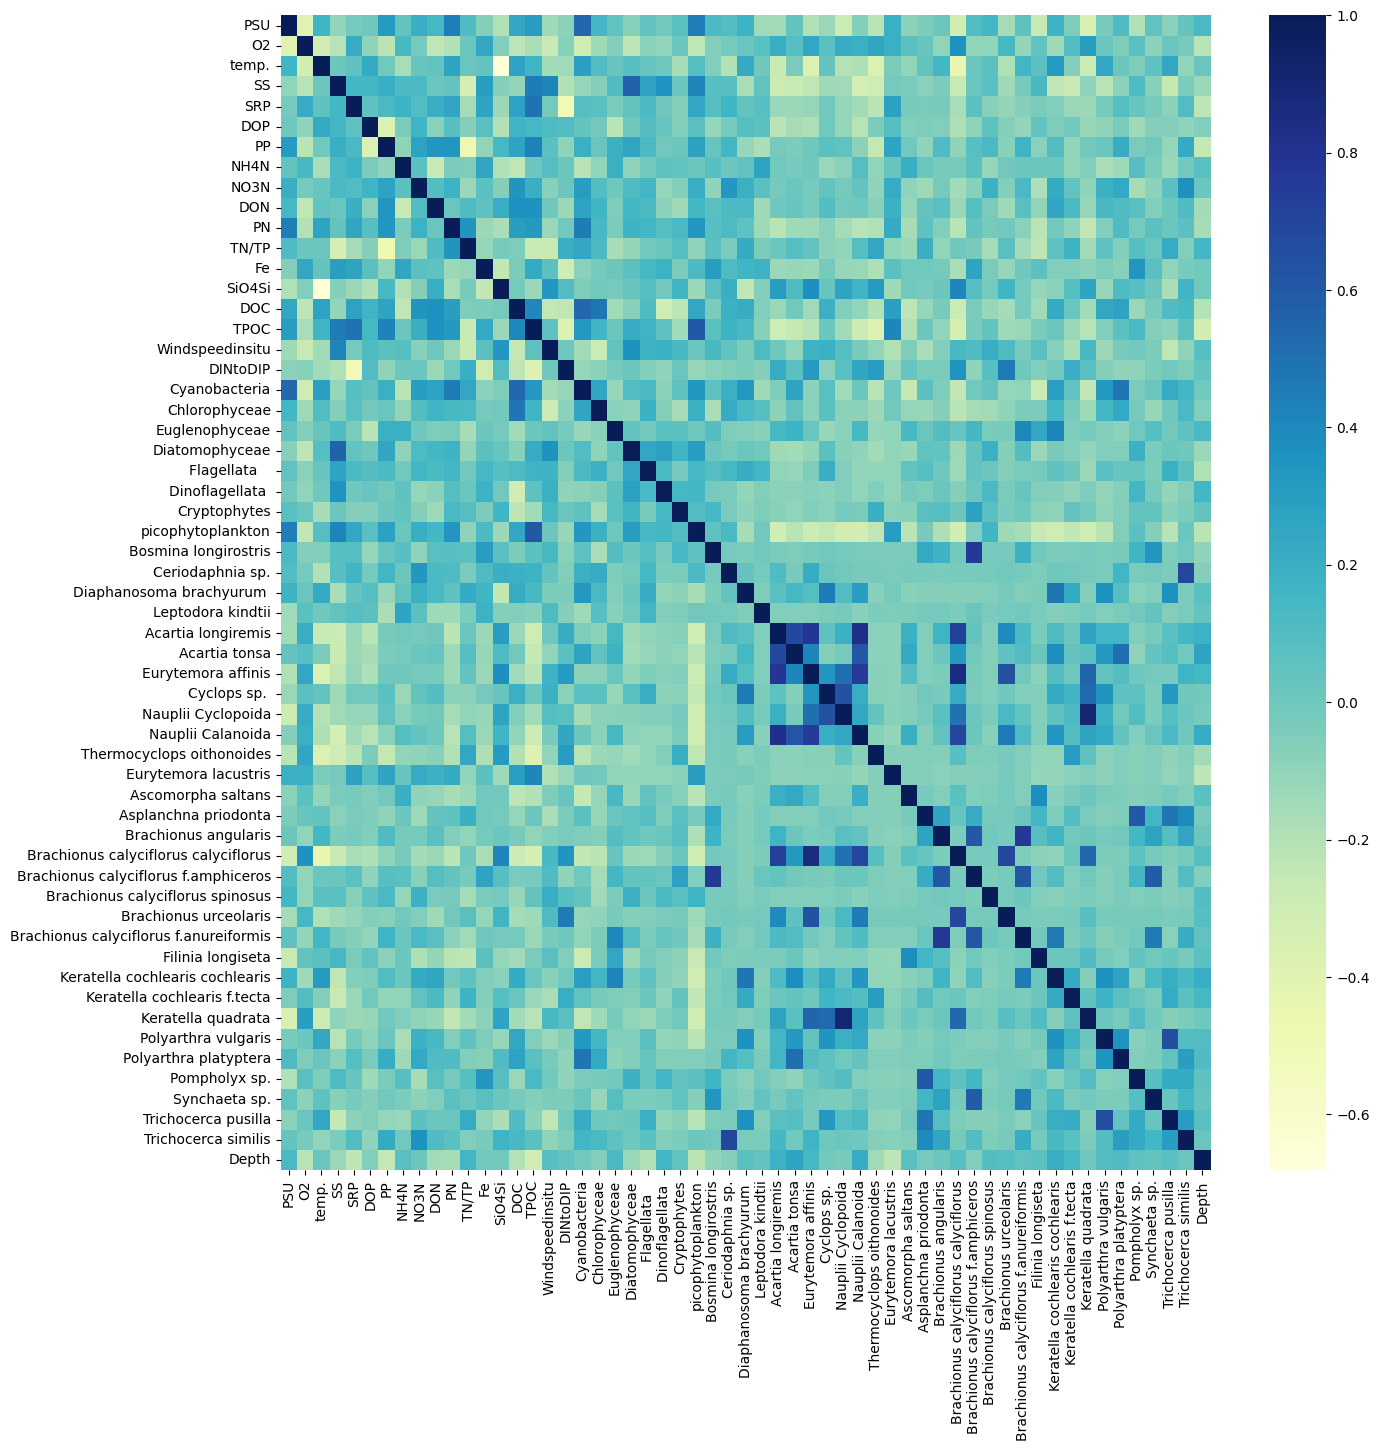

In [4]:
plt.figure(figsize=(15, 15))
sns.heatmap(dftrain.corr(), fmt=".2f", cmap="YlGnBu")

# Opis kolumn dla datasetu VLagun_Total_Years_depth

In [5]:
dftrain.describe()

,PSU,O2,temp.,SS,SRP,DOP,PP,NH4N,NO3N,DON,...,Keratella cochlearis cochlearis,Keratella cochlearis f.tecta,Keratella quadrata,Polyarthra vulgaris,Polyarthra platyptera,Pompholyx sp.,Synchaeta sp.,Trichocerca pusilla,Trichocerca similis,Depth
count,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,...,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000,108.000000
mean,3.306667,10.282222,17.493519,87.850278,15.175000,24.450000,132.189815,0.029389,0.036870,0.567870,...,0.323565,0.039778,0.018676,0.010231,0.010259,0.000824,0.001491,0.000806,0.000537,3.018519
std,0.745787,1.090683,3.080790,38.035436,12.624565,20.917021,51.671639,0.017029,0.016719,0.182766,...,0.816320,0.133677,0.082162,0.033578,0.051646,0.002998,0.007383,0.002281,0.002057,0.575699
min,1.500000,8.420000,10.600000,29.000000,1.000000,0.700000,20.900000,0.002000,0.007000,0.022000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.500000
25%,2.707500,9.475000,16.300000,60.000000,7.375000,10.050000,95.750000,0.019000,0.025000,0.493250,...,0.002000,0.001000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.500000
50%,3.342000,10.025000,18.150000,79.000000,11.850000,16.250000,127.200000,0.027000,0.032000,0.571500,...,0.014500,0.003000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
75%,3.905000,11.027500,20.100000,112.812500,20.150000,34.825000,166.050000,0.035000,0.045000,0.689250,...,0.071500,0.010750,0.003500,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.500000
max,4.500000,12.890000,20.700000,217.500000,88.200000,91.100000,285.100000,0.101000,0.100000,0.975000,...,5.311000,1.265000,0.804000,0.248000,0.437000,0.017000,0.050000,0.013000,0.013000,4.000000


# Wypisanie kolumn dla zdbioru VLagun_Total_Years_depth

In [6]:
dftrain.columns

Index(['PSU', 'O2', 'temp.', 'SS', 'SRP', 'DOP', 'PP', 'NH4N', 'NO3N', 'DON',
       'PN', 'TN/TP', 'Fe', 'SiO4Si', 'DOC', 'TPOC', 'Windspeedinsitu',
       'DINtoDIP', 'Cyanobacteria', 'Chlorophyceae', 'Euglenophyceae',
       'Diatomophyceae', 'Flagellata   ', 'Dinoflagellata ', 'Cryptophytes',
       'picophytoplankton', 'Bosmina longirostris', 'Ceriodaphnia sp.',
       'Diaphanosoma brachyurum ', 'Leptodora kindtii', 'Acartia longiremis',
       'Acartia tonsa', 'Eurytemora affinis', 'Cyclops sp. ',
       'Nauplii Cyclopoida', 'Nauplii Calanoida', 'Thermocyclops oithonoides',
       'Eurytemora lacustris', 'Ascomorpha saltans', 'Asplanchna priodonta',
       'Brachionus angularis', 'Brachionus calyciflorus calyciflorus',
       'Brachionus calyciflorus f.amphiceros',
       'Brachionus calyciflorus spinosus', 'Brachionus urceolaris',
       'Brachionus calyciflorus f.anureiformis', 'Filinia longiseta',
       'Keratella cochlearis cochlearis', 'Keratella cochlearis f.tecta',
    

# Wizualizacja rozkładów cech względem poziomu Depth

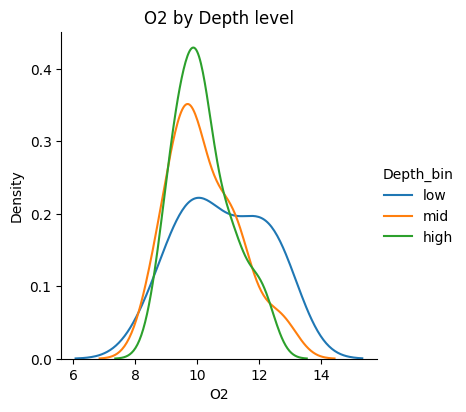

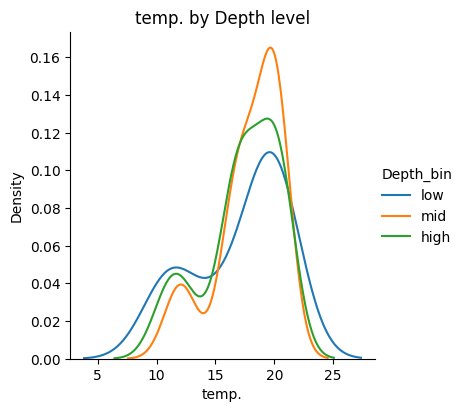

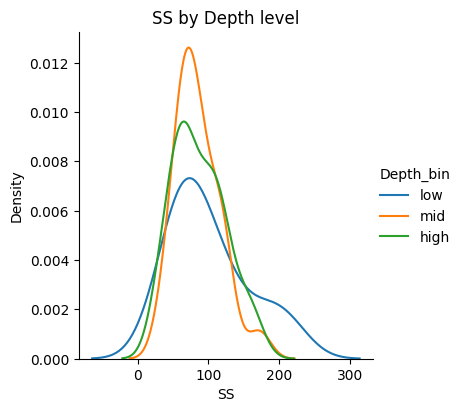

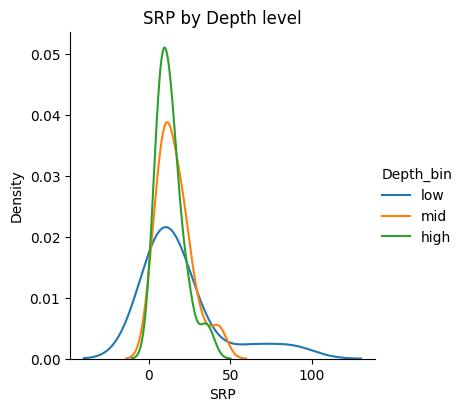

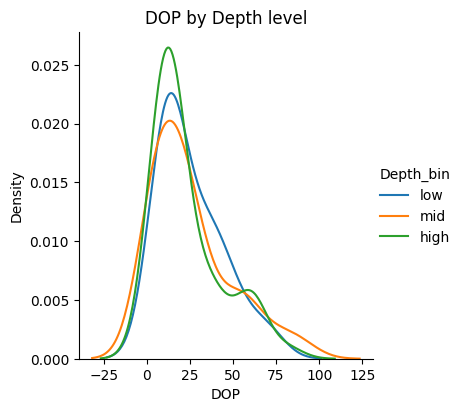

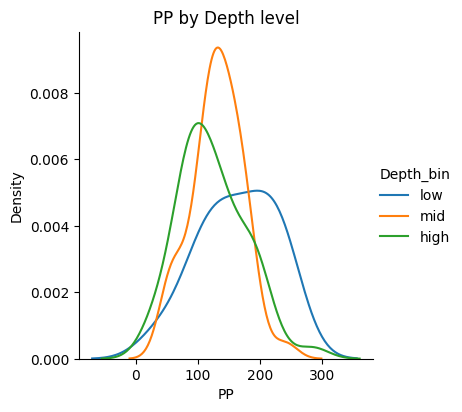

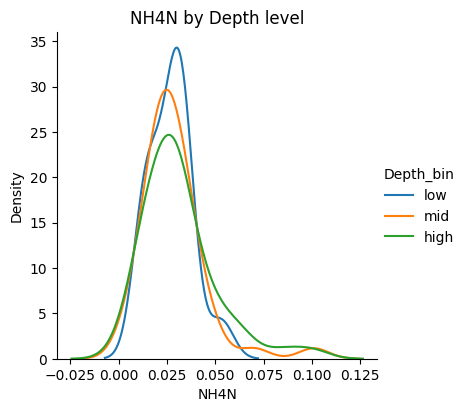

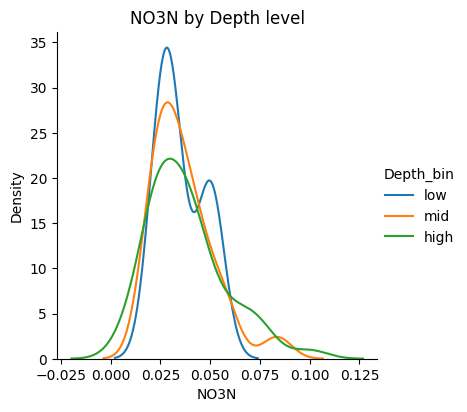

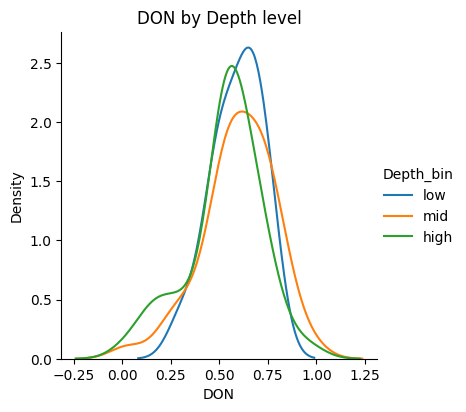

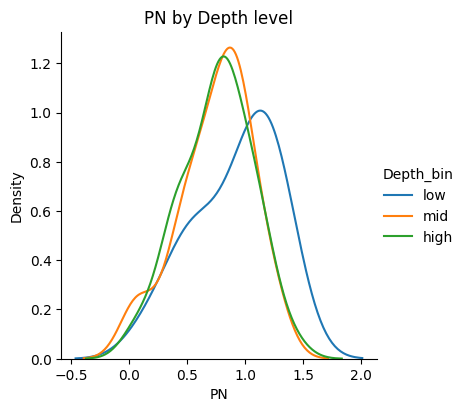

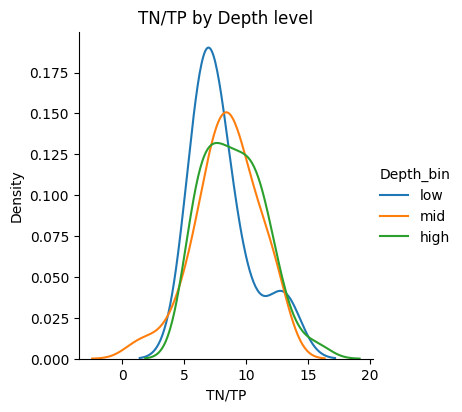

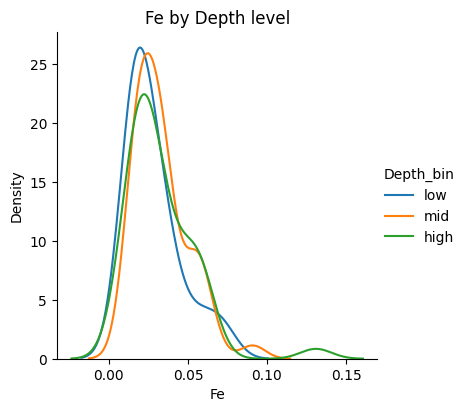

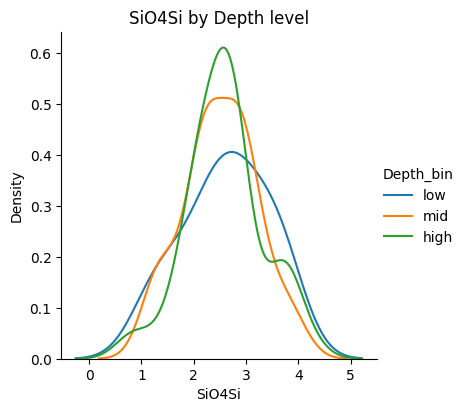

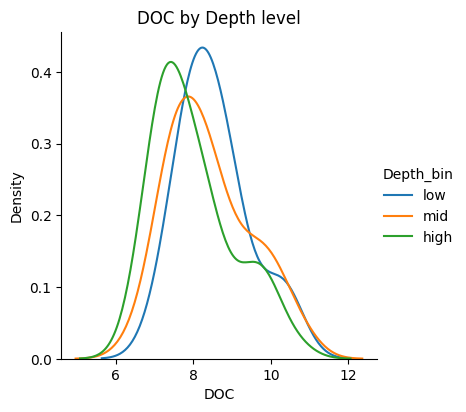

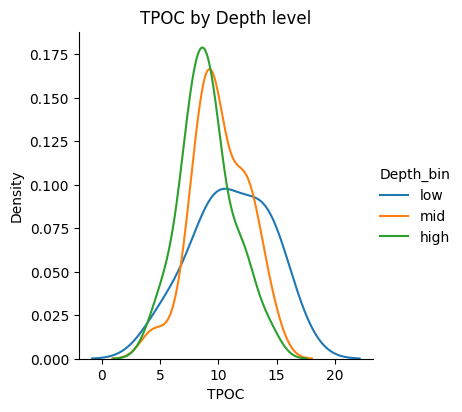

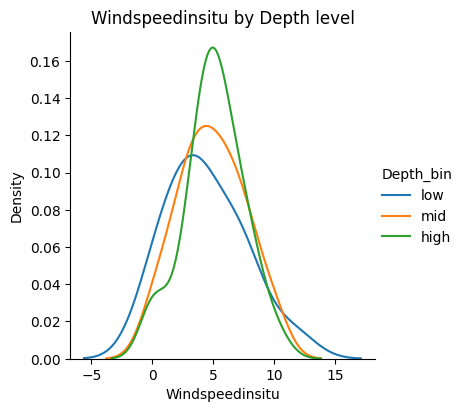

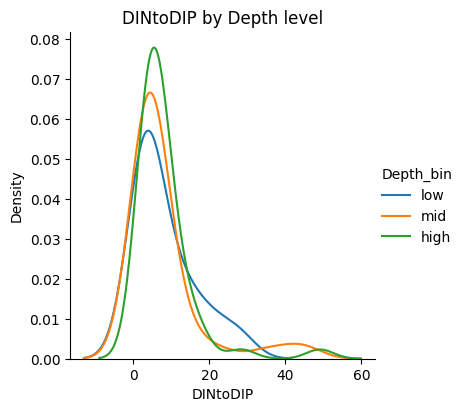

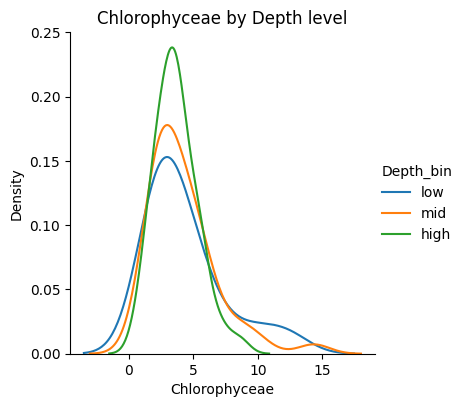

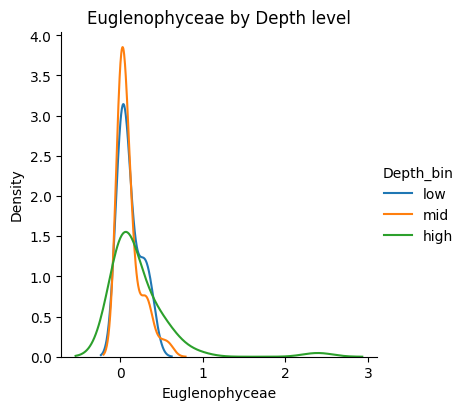

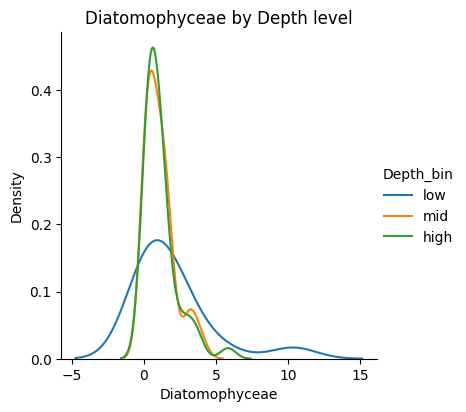

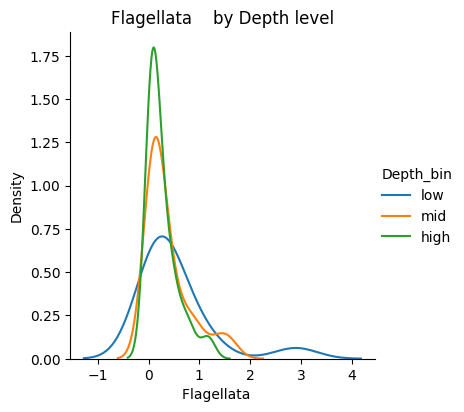

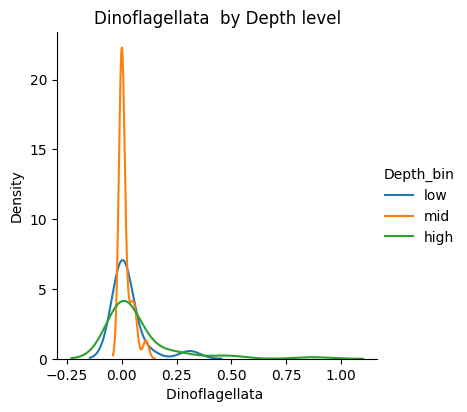

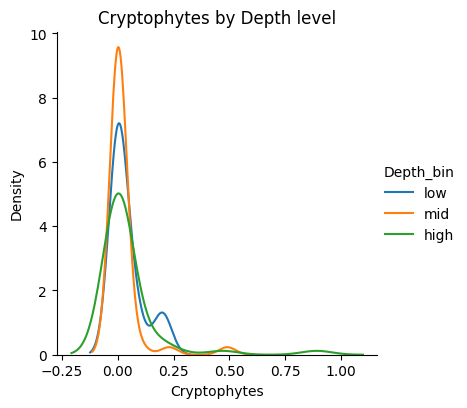

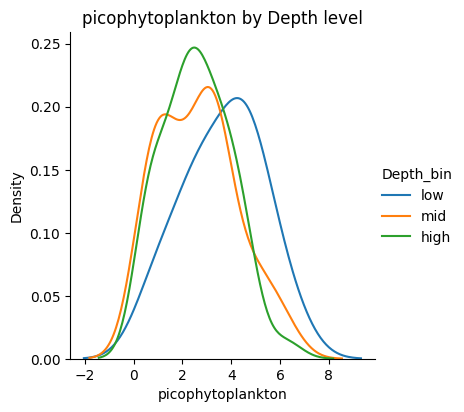

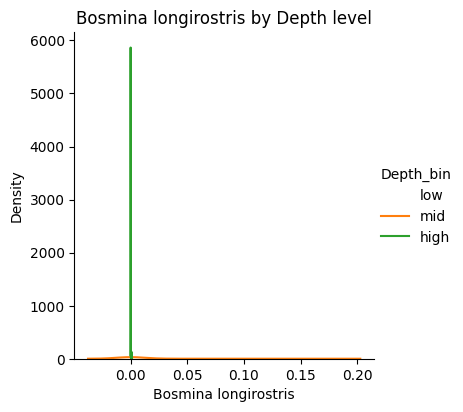

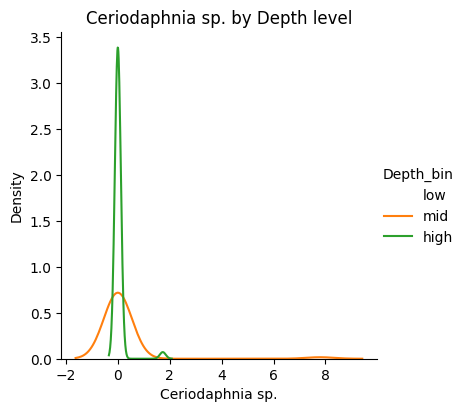

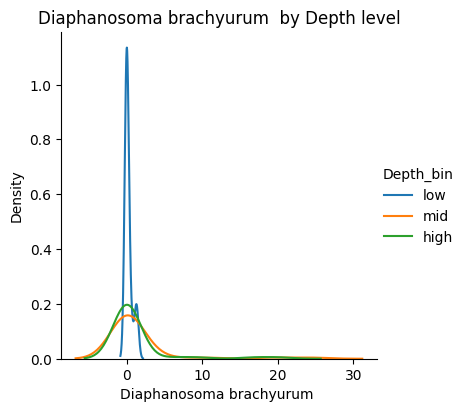

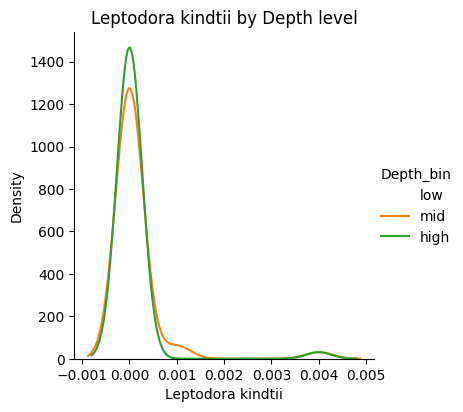

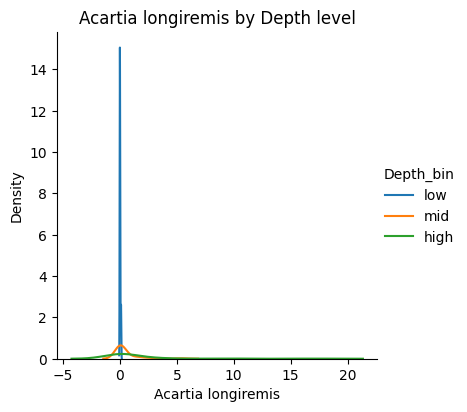

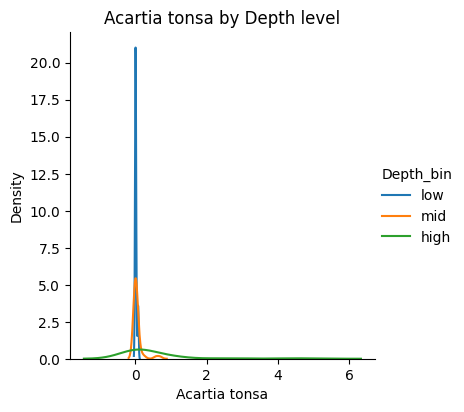

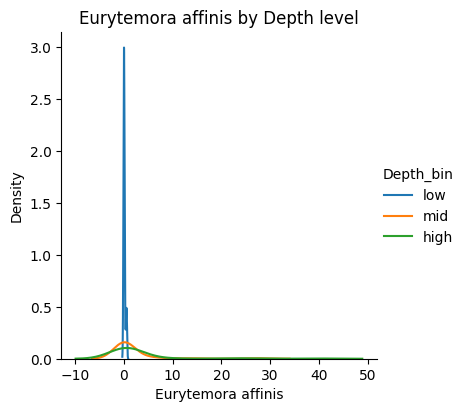

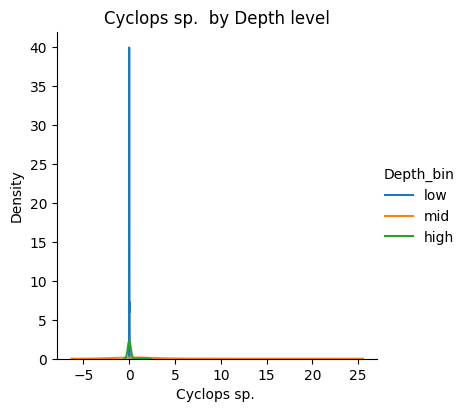

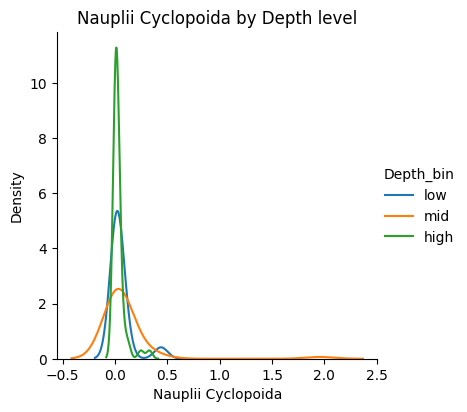

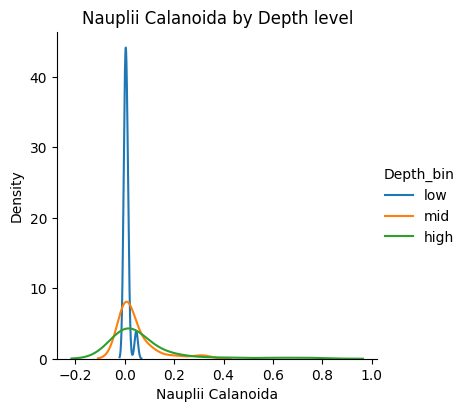

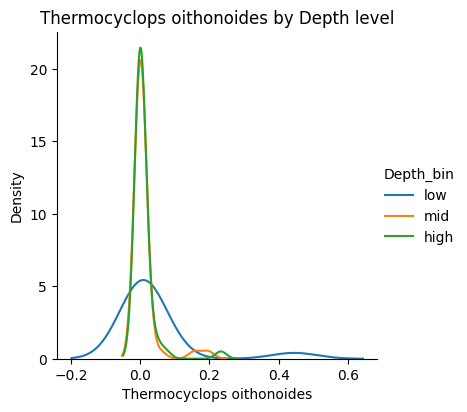

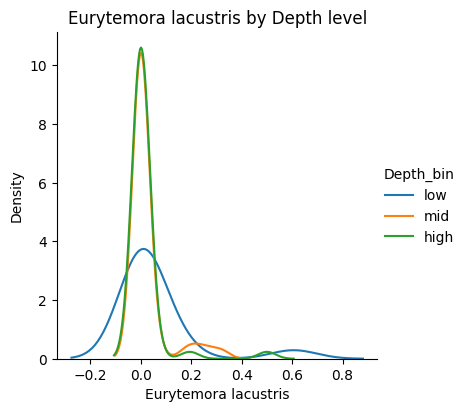

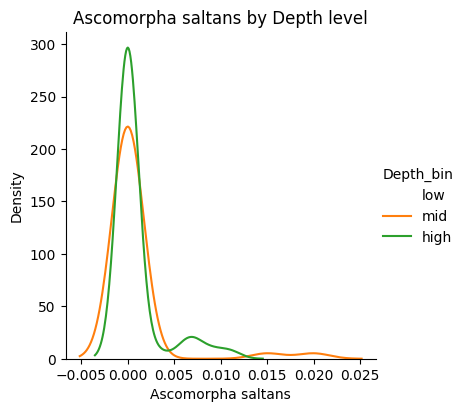

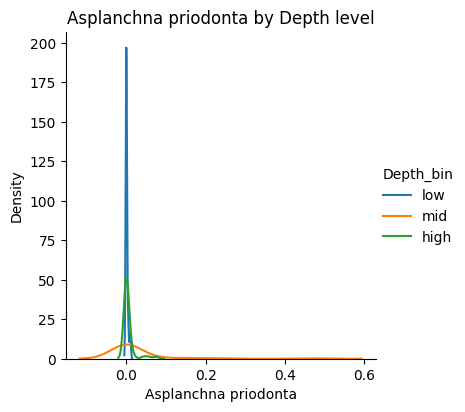

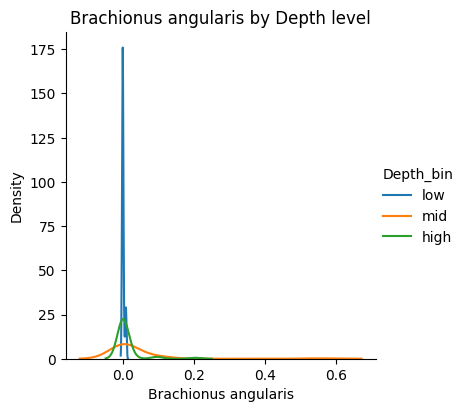

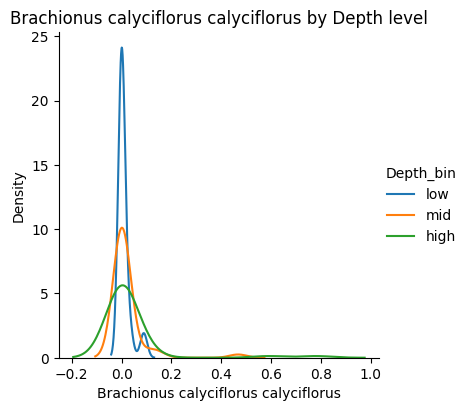

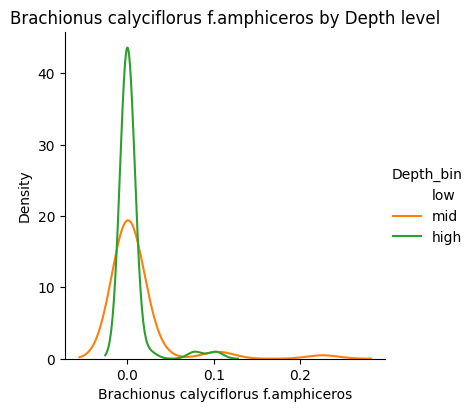

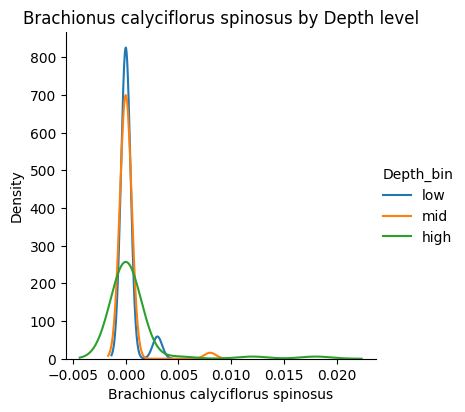

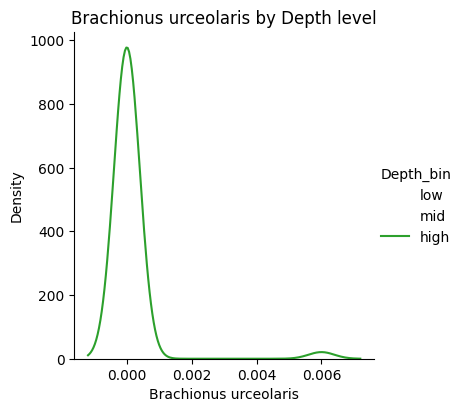

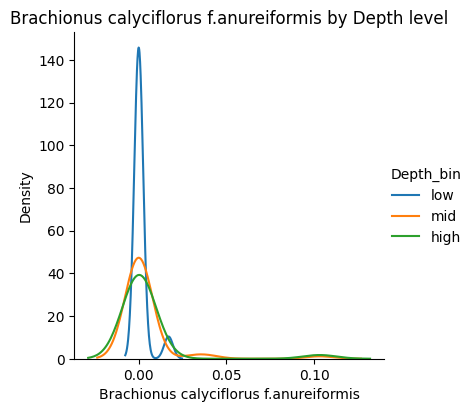

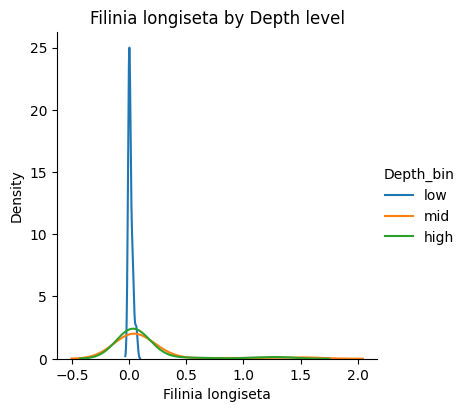

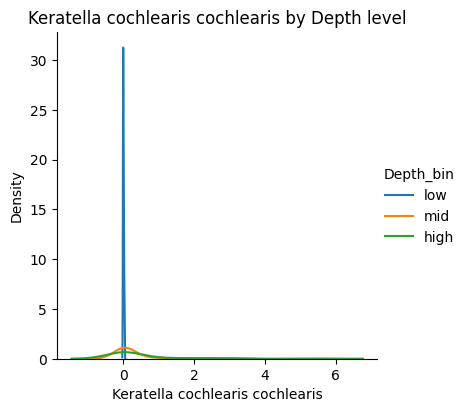

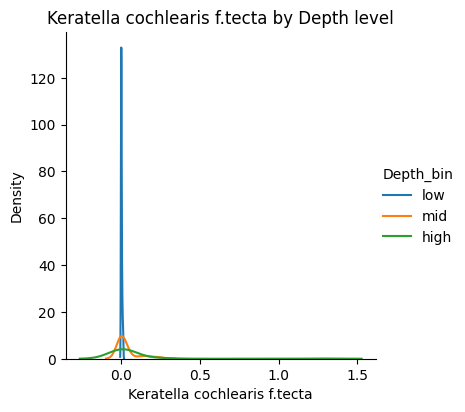

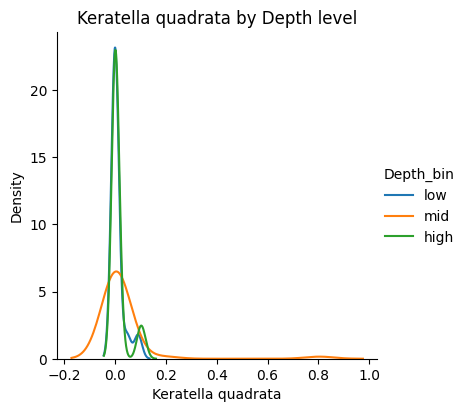

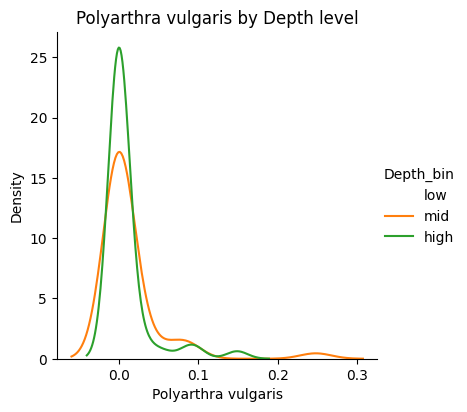

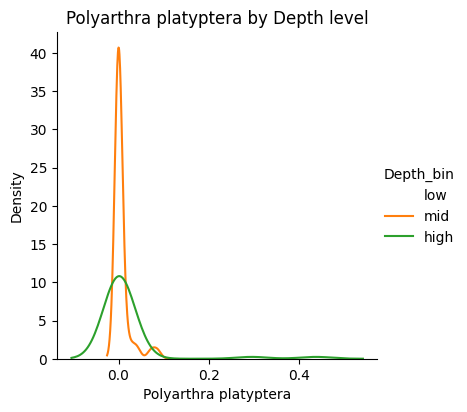

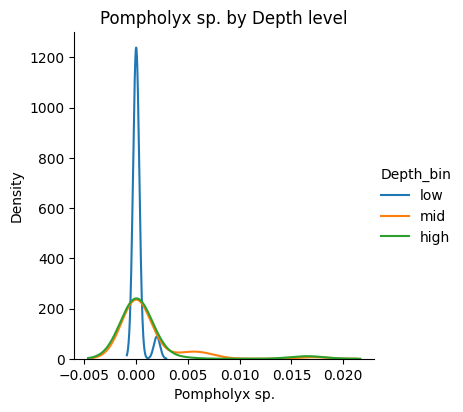

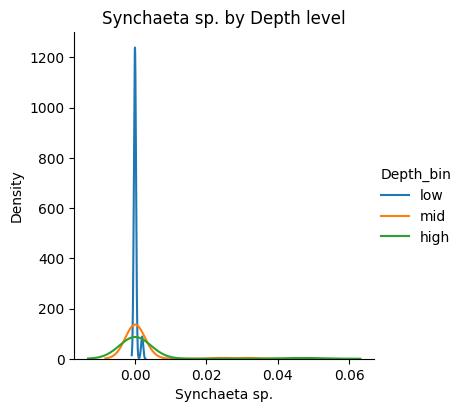

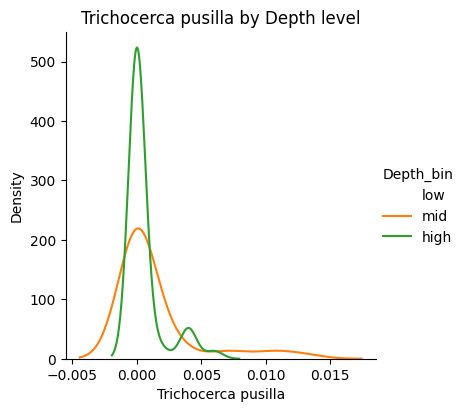

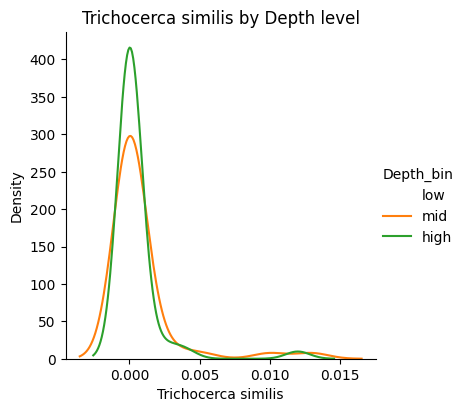

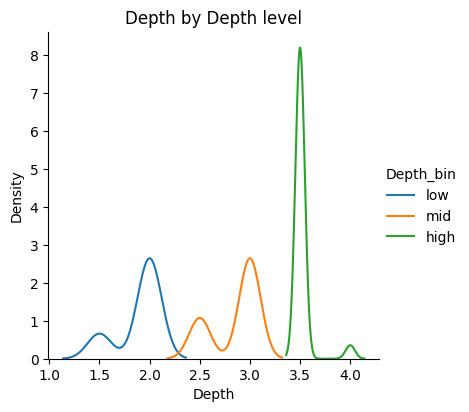

In [7]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd

# Upewniamy się, że kolumna jest liczbowa
dftrain["Depth"] = pd.to_numeric(dftrain["Depth"], errors='coerce')

# Tworzymy kategorię
dftrain["Depth_bin"] = pd.cut(
    dftrain["Depth"],
    bins=3,
    labels=["low", "mid", "high"]
)

# Lista kolumn do rysowania
cols_to_plot = [
    'O2', 'temp.', 'SS', 'SRP', 'DOP', 'PP', 'NH4N', 'NO3N', 'DON',
    'PN', 'TN/TP', 'Fe', 'SiO4Si', 'DOC', 'TPOC', 'Windspeedinsitu',
    'DINtoDIP', 'Chlorophyceae', 'Euglenophyceae',
    'Diatomophyceae', 'Flagellata   ', 'Dinoflagellata ', 'Cryptophytes',
    'picophytoplankton', 'Bosmina longirostris', 'Ceriodaphnia sp.',
    'Diaphanosoma brachyurum ', 'Leptodora kindtii', 'Acartia longiremis',
    'Acartia tonsa', 'Eurytemora affinis', 'Cyclops sp. ',
    'Nauplii Cyclopoida', 'Nauplii Calanoida', 'Thermocyclops oithonoides',
    'Eurytemora lacustris', 'Ascomorpha saltans', 'Asplanchna priodonta',
    'Brachionus angularis', 'Brachionus calyciflorus calyciflorus',
    'Brachionus calyciflorus f.amphiceros',
    'Brachionus calyciflorus spinosus', 'Brachionus urceolaris',
    'Brachionus calyciflorus f.anureiformis', 'Filinia longiseta',
    'Keratella cochlearis cochlearis', 'Keratella cochlearis f.tecta',
    'Keratella quadrata', 'Polyarthra vulgaris', 'Polyarthra platyptera',
    'Pompholyx sp.', 'Synchaeta sp.', 'Trichocerca pusilla',
    'Trichocerca similis', 'Depth'
]

# Tworzymy wykresy KDE dla każdej kolumny z podziałem na Depth_bin
for col in cols_to_plot:
    if col in dftrain.columns:
        g = sns.FacetGrid(dftrain, hue="Depth_bin", height=4)
        g.map(sns.kdeplot, col)
        g.add_legend()
        plt.title(f"{col} by Depth level")
        plt.show()


# Selekcja cech testem Chi-Kwadrat

In [10]:
import scipy.stats as stats
from scipy.stats import chi2_contingency
import pandas as pd

class ChiSquare:
    def __init__(self, dataframe):
        self.df = dataframe
        self.p = None #P-Value
        self.chi2 = None #Chi Test Statistic
        self.dof = None

        self.dfObserved = None
        self.dfExpected = None

    def _print_chisquare_result(self, colX, alpha):
        result = ""
        if self.p < alpha:
            result="{0} is IMPORTANT for Prediction".format(colX)
        else:
            result="{0} is NOT an important predictor. (Discard {0} from model)".format(colX)

        print(result)

    def TestIndependence(self, colX, colY, alpha=0.05):
        X = self.df[colX].astype(str)
        Y = self.df[colY].astype(str)
        self.dfObserved = pd.crosstab(Y,X)
        chi2, p, dof, expected = stats.chi2_contingency(self.dfObserved.values)
        self.p = p
        self.chi2 = chi2
        self.dof = dof

        self.dfExpected = pd.DataFrame(expected, columns=self.dfObserved.columns, index=self.dfObserved.index)

        self._print_chisquare_result(colX, alpha)

#Initialize ChiSquare Class
cT = ChiSquare(dftrain)

#Feature Selection
testColumns = [
    'O2', 'temp.', 'SS', 'SRP', 'DOP', 'PP', 'NH4N', 'NO3N', 'DON',
    'PN', 'TN/TP', 'Fe', 'SiO4Si', 'DOC', 'TPOC', 'Windspeedinsitu',
    'DINtoDIP', 'Chlorophyceae', 'Euglenophyceae',
    'Diatomophyceae', 'Flagellata   ', 'Dinoflagellata ', 'Cryptophytes',
    'picophytoplankton', 'Bosmina longirostris', 'Ceriodaphnia sp.',
    'Diaphanosoma brachyurum ', 'Leptodora kindtii', 'Acartia longiremis',
    'Acartia tonsa', 'Eurytemora affinis', 'Cyclops sp. ',
    'Nauplii Cyclopoida', 'Nauplii Calanoida', 'Thermocyclops oithonoides',
    'Eurytemora lacustris', 'Ascomorpha saltans', 'Asplanchna priodonta',
    'Brachionus angularis', 'Brachionus calyciflorus calyciflorus',
    'Brachionus calyciflorus f.amphiceros',
    'Brachionus calyciflorus spinosus', 'Brachionus urceolaris',
    'Brachionus calyciflorus f.anureiformis', 'Filinia longiseta',
    'Keratella cochlearis cochlearis', 'Keratella cochlearis f.tecta',
    'Keratella quadrata', 'Polyarthra vulgaris', 'Polyarthra platyptera',
    'Pompholyx sp.', 'Synchaeta sp.', 'Trichocerca pusilla',
    'Trichocerca similis', 'Depth'
]


for var in testColumns:
    cT.TestIndependence(colX=var, colY="Depth")

O2 is NOT an important predictor. (Discard O2 from model)
temp. is NOT an important predictor. (Discard temp. from model)
SS is NOT an important predictor. (Discard SS from model)
SRP is NOT an important predictor. (Discard SRP from model)
DOP is NOT an important predictor. (Discard DOP from model)
PP is NOT an important predictor. (Discard PP from model)
NH4N is NOT an important predictor. (Discard NH4N from model)
NO3N is NOT an important predictor. (Discard NO3N from model)
DON is NOT an important predictor. (Discard DON from model)
PN is NOT an important predictor. (Discard PN from model)
TN/TP is NOT an important predictor. (Discard TN/TP from model)
Fe is NOT an important predictor. (Discard Fe from model)
SiO4Si is NOT an important predictor. (Discard SiO4Si from model)
DOC is NOT an important predictor. (Discard DOC from model)
TPOC is NOT an important predictor. (Discard TPOC from model)
Windspeedinsitu is NOT an important predictor. (Discard Windspeedinsitu from model)
DINtoD

# Ważne kolumny do predykcji

- Diaphanosoma brachyurum
- Eurytemora affinis
- Eurytemora lacustris
- Keratella cochlearis cochlearis
- Depth

In [9]:
import itertools
import numpy as np
import pandas as pd

# Wybieramy tylko kolumny numeryczne
num_cols = dftrain.select_dtypes(include=np.number).columns

# Wykrywanie outlierów
outlier_list = []

for col in num_cols:
    q1 = np.percentile(dftrain[col], 25)
    q3 = np.percentile(dftrain[col], 75)
    step = 1.5 * (q3 - q1)
    
    # Wiersze, które są outlierami
    outliers_rows = dftrain.loc[~((dftrain[col] >= q1 - step) & (dftrain[col] <= q3 + step)), :]
    
    print(f"Data points considered outliers for the feature '{col}':")
    print(outliers_rows.index.tolist())
    
    outlier_list.append(list(outliers_rows.index))

# 3. Łączenie wszystkich indeksów outlierów
all_outliers = list(itertools.hain.from_iterable(outlier_list))
uniq_outlier = list(set(all_outliers))

# 4. Wybranie tylko tych indeksy, które pojawiają się więcej niż raz
dup_outliers = [i for i in uniq_outlier if all_outliers.count(i) > 1]

# 5. Filtracja tylko indeksy istniejące w dftrain
dup_outliers_valid = [i for i in dup_outliers if i in dftrain.index]

# 6. Tworzenie nowego DataFrame bez outlierów
real_data = dftrain.drop(index=dup_outliers_valid).reset_index(drop=True)

# 7. Informacje o wynikach
print("Outliers list:\n", uniq_outlier)
print("Length of outliers list:", len(uniq_outlier))

print("Duplicate outliers (to remove):\n", dup_outliers_valid)
print("Length of duplicates list:", len(dup_outliers_valid))

print("Shape of cleaned DataFrame:", real_data.shape)

Data points considered outliers for the feature 'PSU':
[]
Data points considered outliers for the feature 'O2':
[]
Data points considered outliers for the feature 'temp.':
[]
Data points considered outliers for the feature 'SS':
[143, 64]
Data points considered outliers for the feature 'SRP':
[113, 146, 110, 28, 112]
Data points considered outliers for the feature 'DOP':
[16, 111, 7, 48]
Data points considered outliers for the feature 'PP':
[115]
Data points considered outliers for the feature 'NH4N':
[47, 53, 5, 83, 8, 63, 54]
Data points considered outliers for the feature 'NO3N':
[111, 105, 115, 116]
Data points considered outliers for the feature 'DON':
[4, 25, 53, 48, 129, 1]
Data points considered outliers for the feature 'PN':
[]
Data points considered outliers for the feature 'TN/TP':
[21, 129]
Data points considered outliers for the feature 'Fe':
[151, 136, 89]
Data points considered outliers for the feature 'SiO4Si':
[39, 21, 20]
Data points considered outliers for the featur

AttributeError: module 'itertools' has no attribute 'hain'